# Study 9: GP Lengthscale Grid Search

Tests whether fitting the GP `length_scale` significantly improves fit to participant prevalence ratings,
relative to a null model with large lengthscale (features generalize uniformly, ignoring embedding proximity).

For each candidate `length_scale`, runs the full pipeline:
1. Joint MCMC over all pseudocoherences `(y_train, y'_1, ..., y'_J)`
2. Beta mixture fitting → `E[p' | u, θ]` per test feature
3. Pearson r and log likelihood against empirical participant ratings

**Scientific question**: does the GP lengthscale (feature-space generalization radius) explain variance
in human prevalence judgments beyond a flat baseline?

In [1]:
import sys, csv, pickle as pkl
sys.path.insert(0, ".")

import numpy as np
import jax
import jax.numpy as jnp
import blackjax
import matplotlib.pyplot as plt

from model_jax import (
    make_log_density_fn_joint,
    fit_beta_mixtures_all_features,
)

In [2]:
with open('../features/set2_features_dataframe.pkl', 'rb') as f:
    df = pkl.load(f)

with open('../../data/study9.csv') as f:
    rows = list(csv.reader(f))
CSV_HEADER = rows[0]
data_rows  = rows[3:]

print(f"Features: {len(df)} total, {(df.split=='train').sum()} train, {(df.split=='test').sum()} test")
print(f"Participants: {len(data_rows)}")

Features: 60 total, 45 train, 15 test
Participants: 402


In [3]:
CSV_TO_FEATURE = {
    'diet_can_eat_spicy_1':  'can eat spicy food',
    'diet_breakfast_late_1': 'eat breakfast very late',
    'diet_five_meals_day_1': 'eat five meals a day',
    'diet_like_juice_pulp_1':'like juice with pulp',
    'diet_pepper_on_all_1':  'put pepper on all their foods',
    'pers_cry_easily_1':     'cry easily',
    'pers_collect_rocks_1':  'like to collect rocks',
    'pers_like_to_dance_1':  'like to dance',
    'pers_like_highfive_1':  'like to give high-fives',
    'pers_read_books_1':     'like to read books',
    'phys_can_roll_tongue_1':'can roll their tongue',
    'phys_can_snap_toes_1':  'can snap with their toes',
    'phys_can_wiggle_ears_1':'can wiggle their ears',
    'phys_cold_hands_feet_1':'have cold hands and feet',
    'phys_snore_sleep_1':    'snore when they sleep',
}
TEST_CSV_COLS = list(CSV_TO_FEATURE.keys())
feat_idx = df.set_index('feature')

train_df = df[df.split == 'train']
x_train  = jnp.array(train_df[['x_2d', 'y_2d']].values)          # (n_train, 2)
u_train  = jnp.zeros(len(train_df), dtype=jnp.int32)              # all generic

test_feature_names = [CSV_TO_FEATURE[c] for c in TEST_CSV_COLS]
x_test = jnp.array(
    [feat_idx.loc[name, ['x_2d', 'y_2d']].values for name in test_feature_names]
)  # (J, 2)

print(f"x_train: {x_train.shape}, x_test: {x_test.shape}")

x_train: (45, 2), x_test: (15, 2)


In [4]:
col_indices = [CSV_HEADER.index(c) for c in TEST_CSV_COLS]

ratings = []
for row in data_rows:
    try:
        vals = [int(row[i]) / 100.0 for i in col_indices]
        ratings.append(vals)
    except (ValueError, IndexError):
        pass

responses = jnp.array(ratings)  # (N, J)
N, J = responses.shape
print(f"responses: {responses.shape}  (N={N} participants, J={J} features)")

empirical_mean = np.array(responses.mean(axis=0))  # (J,)

responses: (402, 15)  (N=402 participants, J=15 features)


In [5]:
# Lengthscales to sweep. Large values (e.g. 10.0) approach the null:
# all features share the same pseudocoherence regardless of embedding proximity.
LENGTH_SCALES = [0.1, 0.2, 0.4, 0.8, 1.5, 3.0, 10.0]

BASE_PARAMS = {
    'mu_0':         0.0,
    'output_scale': 1.5,
    'beta':         3.0,
}

In [6]:
n_warmup  = 500
n_samples = 2000
rng_np    = np.random.default_rng(0)

results = []  # one dict per length_scale

for ls in LENGTH_SCALES:
    print(f"\n=== length_scale = {ls} ===")
    params = {**BASE_PARAMS, 'length_scale': ls}

    log_density_fn = make_log_density_fn_joint(u_train, x_train, x_test, params)

    init_position = {
        'training_coherences': jnp.zeros(x_train.shape[0]),
        'test_coherences':     jnp.zeros(J),
    }

    rng_key = jax.random.PRNGKey(0)  # same seed per ls for comparability
    rng_key, warmup_key = jax.random.split(rng_key)
    warmup = blackjax.window_adaptation(blackjax.nuts, log_density_fn)
    (state, nuts_params), _ = warmup.run(warmup_key, init_position, num_steps=n_warmup)
    print(f"  Warmup done. Step size: {nuts_params['step_size']:.4f}")

    nuts = blackjax.nuts(log_density_fn, **nuts_params)

    @jax.jit
    def one_step(state, key):
        return nuts.step(key, state)

    keys = jax.random.split(rng_key, n_samples)
    test_coherences_all = []
    for key in keys[:-1]:
        state, _ = one_step(state, key)
        test_coherences_all.append(np.array(state.position['test_coherences']))
    test_coherences_all = np.array(test_coherences_all)  # (S, J)

    pz1_samples_all = [
        np.array(jax.nn.sigmoid(jnp.array(test_coherences_all[:, j]))) for j in range(J)
    ]
    pz1_test = np.array([float(np.mean(s)) for s in pz1_samples_all])  # (J,)

    # Beta mixture fit with resampled pz1 to propagate posterior uncertainty
    pz1_broadcast = jnp.array(
        np.stack([
            rng_np.choice(pz1_samples_all[j], size=N, replace=True)
            for j in range(J)
        ], axis=1)
    )  # (N, J)
    beta_params = fit_beta_mixtures_all_features(responses, pz1_broadcast)

    alpha_kl  = np.array(beta_params[:, 0])
    beta_kl   = np.array(beta_params[:, 1])
    alpha_nkl = np.array(beta_params[:, 2])
    beta_nkl  = np.array(beta_params[:, 3])

    mean_kl  = alpha_kl  / (alpha_kl  + beta_kl)
    mean_nkl = alpha_nkl / (alpha_nkl + beta_nkl)
    pred_prevalence = pz1_test * mean_kl + (1 - pz1_test) * mean_nkl  # (J,)

    pearson_r = float(np.corrcoef(empirical_mean, pred_prevalence)[0, 1])
    print(f"  Pearson r = {pearson_r:.3f}")

    results.append({
        'length_scale':     ls,
        'pz1_test':         pz1_test,
        'pred_prevalence':  pred_prevalence,
        'pearson_r':        pearson_r,
        'beta_params':      np.array(beta_params),
    })

print("\nGrid search complete.")


=== length_scale = 0.1 ===
  Warmup done. Step size: 0.0089
  Pearson r = 0.917

=== length_scale = 0.2 ===
  Warmup done. Step size: 0.0082


/opt/miniconda3/envs/compgenerics/lib/python3.11/site-packages/scipy/_lib/array_api_compat/numpy/_aliases.py:106: RuntimeWarning: overflow encountered in cast
  return x.astype(dtype=dtype, copy=copy)


  Pearson r = 0.888

=== length_scale = 0.4 ===
  Warmup done. Step size: 0.0098
  Pearson r = 0.905

=== length_scale = 0.8 ===
  Warmup done. Step size: 0.0155
  Pearson r = 0.941

=== length_scale = 1.5 ===
  Warmup done. Step size: 0.0117
  Pearson r = 0.932

=== length_scale = 3.0 ===
  Warmup done. Step size: 0.0319
  Pearson r = 0.917

=== length_scale = 10.0 ===
  Warmup done. Step size: 0.0226
  Pearson r = 0.930

Grid search complete.


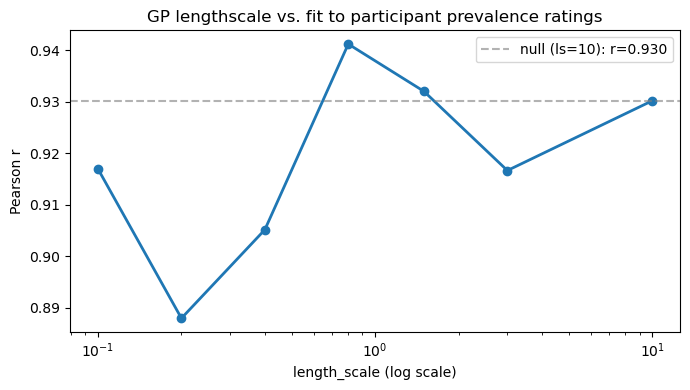

Best length_scale: 0.8  (Pearson r = 0.941)
Null length_scale: 10.0  (Pearson r = 0.930)


In [7]:
# Pearson r vs lengthscale
ls_vals = [r['length_scale'] for r in results]
rs      = [r['pearson_r']    for r in results]

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(ls_vals, rs, 'o-', lw=2)
ax.axhline(rs[-1], color='gray', linestyle='--', alpha=0.6, label=f'null (ls=10): r={rs[-1]:.3f}')
ax.set_xlabel('length_scale (log scale)')
ax.set_ylabel('Pearson r')
ax.set_title('GP lengthscale vs. fit to participant prevalence ratings')
ax.legend()
plt.tight_layout()
plt.show()

best = max(results, key=lambda r: r['pearson_r'])
print(f"Best length_scale: {best['length_scale']}  (Pearson r = {best['pearson_r']:.3f})")
print(f"Null length_scale: {ls_vals[-1]}  (Pearson r = {rs[-1]:.3f})")

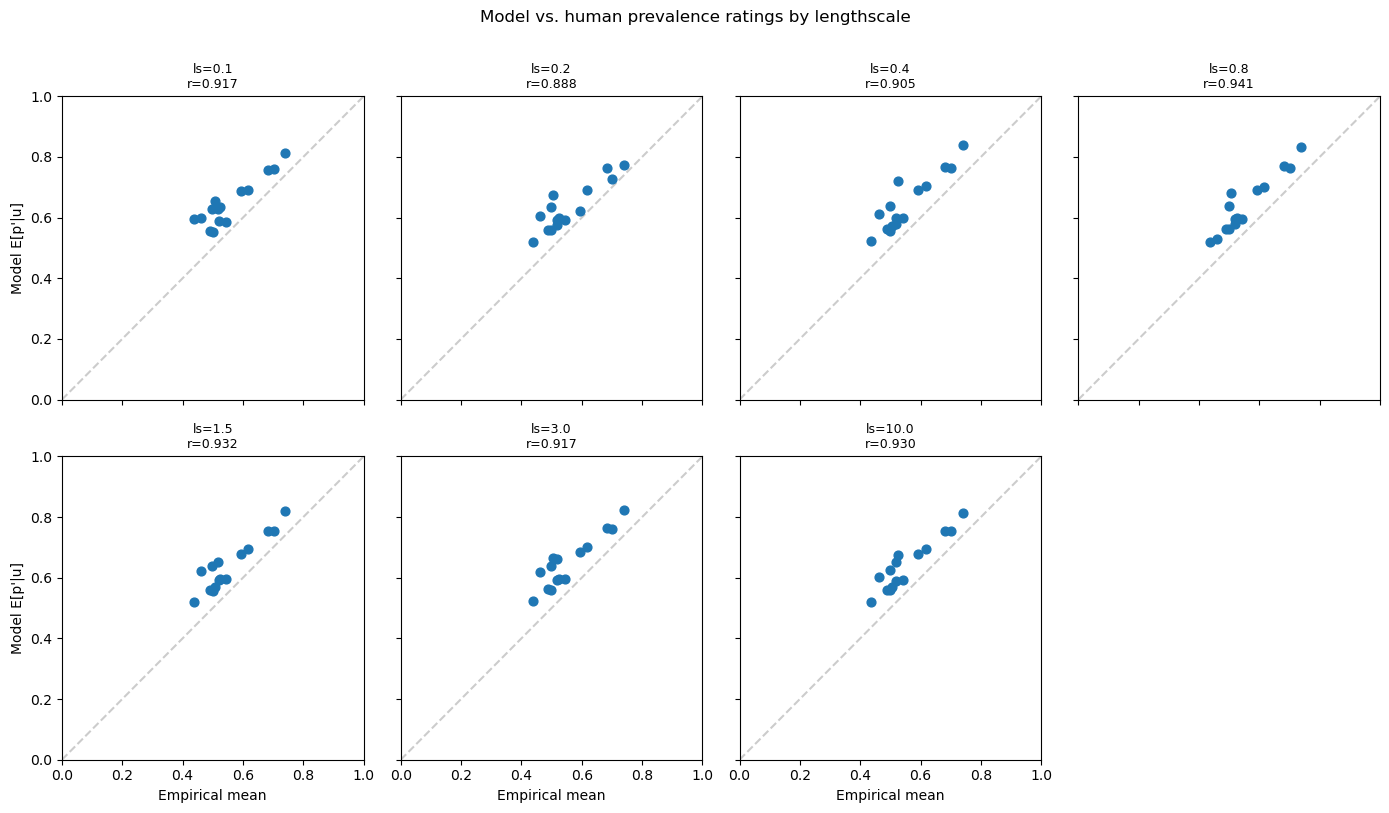

In [8]:
# Scatter plots: predicted vs empirical for each lengthscale
ncols = 4
nrows = (len(results) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 4), sharey=True, sharex=True)
axes = axes.flatten()

lims = [0, 1]
for i, (res, ax) in enumerate(zip(results, axes)):
    ax.scatter(empirical_mean, res['pred_prevalence'], zorder=3, s=40)
    ax.plot(lims, lims, '--', color='gray', alpha=0.4)
    ax.set_title(f"ls={res['length_scale']}\nr={res['pearson_r']:.3f}", fontsize=9)
    ax.set_xlim(lims); ax.set_ylim(lims)
    if i % ncols == 0:
        ax.set_ylabel("Model E[p'|u]")
    if i >= (nrows - 1) * ncols:
        ax.set_xlabel('Empirical mean')

for ax in axes[len(results):]:
    ax.set_visible(False)

plt.suptitle('Model vs. human prevalence ratings by lengthscale', y=1.01)
plt.tight_layout()
plt.show()

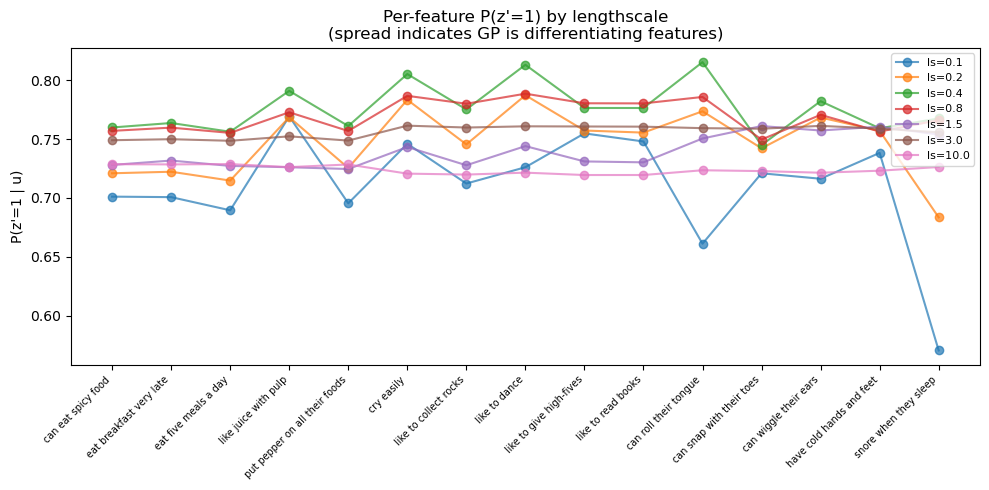

In [9]:
# P(z'=1) per feature across lengthscales — shows how much the GP is differentiating features
fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(J)
for res in results:
    ax.plot(x_pos, res['pz1_test'], 'o-', alpha=0.7, label=f"ls={res['length_scale']}")
ax.set_xticks(x_pos)
ax.set_xticklabels(test_feature_names, rotation=45, ha='right', fontsize=7)
ax.set_ylabel("P(z'=1 | u)")
ax.set_title("Per-feature P(z'=1) by lengthscale\n(spread indicates GP is differentiating features)")
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()